# Self-Refinement: Can Small LLMs Improve Their Own Output?

**Course:** CS4063 – Natural Language Processing
**Group:** Hashir Rauf (23L-2572) · Bilal Ahmad (23L-2534) · Muhammad Saad (23L-2620) | BDS-6B

---

## Research Question
> *Can small LLMs (3B–7B) improve their own output through iterative self-refinement — and under what conditions does it help vs. hurt?*

**Literature Gap Addressed:** Existing self-refinement papers (Self-Refine, Self-Polish, Reflexion, SSR) exclusively test on GPT-3.5/GPT-4/PaLM-540B. No paper systematically studies these methods at sub-10B open-source scale on local hardware.

## Experimental Conditions

| ID | Method | Description |
|---|---|---|
| B1 | Zero-shot | Single-pass, no refinement |
| B2 | Chain-of-Thought (CoT) | Think step-by-step before answering |
| B3 | Rephrase-and-Respond (RaR) | Rephrase input, then generate |
| SR-1 | Self-Refine k=1 | Generate → Feedback → Refine (×1) |
| SR-2 | Self-Refine k=2 | Generate → Feedback → Refine (×2) |
| SR-3 | Self-Refine k=3 | Generate → Feedback → Refine (×3) |

## Task
**Primary:** Text Summarization on CNN/DailyMail (50 samples)
**Metrics:** ROUGE-1, ROUGE-2, ROUGE-L, BERTScore F1, Diversity (collapse detection)


## 0. Installation

Run once. Safe to skip if packages are already installed.

In [6]:
import subprocess, sys

packages = [
    "requests",
    "rouge-score",
    "bert-score",
    "datasets",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "sentence-transformers",
    "tqdm",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("All packages installed.")


All packages installed.


## 1. Imports & Configuration

In [7]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from tqdm import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

#  CONFIGURATION 
OLLAMA_BASE_URL   = "http://localhost:11434"   # Ollama server URL (same device)
PRIMARY_MODEL     = "gemma4:e4b"             # small model
SECONDARY_MODEL   = "mistral:7b"              # medium model (set None to skip)

N_SAMPLES         = 20     # samples per task (use 20 for a quick test run)
MAX_ITERATIONS    = 3      # max self-refine iterations
TEMPERATURE       = 0.7    # generation temperature
FEEDBACK_TEMP     = 0.3    # lower temp → more consistent feedback
MAX_ARTICLE_WORDS = 300    # truncate long articles to fit context window
MAX_CONTEXT_WORDS = 150    # truncate SQuAD context
MAX_TOKENS_GEN    = 256    # max generated tokens (generation step)
MAX_TOKENS_FB     = 150    # max generated tokens (feedback step)
OLLAMA_TIMEOUT    = 180    # seconds per Ollama request
SEED              = 42

RESULTS_DIR = "results"
DATA_DIR    = "data"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR,    exist_ok=True)

ACTIVE_MODELS = [m for m in [PRIMARY_MODEL, SECONDARY_MODEL] if m]
print("Active models:", ACTIVE_MODELS)
print("Results directory:", os.path.abspath(RESULTS_DIR))


Active models: ['gemma4:e4b', 'mistral:7b']
Results directory: e:\Literature\Semester 6\NLP\Project\results


## 2. Ollama API Wrapper

In [8]:
def call_ollama(
    prompt: str,
    model: str = PRIMARY_MODEL,
    temperature: float = TEMPERATURE,
    max_tokens: int = MAX_TOKENS_GEN,
    timeout: int = OLLAMA_TIMEOUT,
) -> str:
    """Send a prompt to local Ollama via /api/chat and return the model's response text."""
    payload = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "think": False,  # disable reasoning tokens — cuts inference time 5-10x on thinking models
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens,
            "seed": SEED,
            "num_ctx": 2048,  # cap context window; default 8k+ is unnecessarily large for our prompts
        },
    }
    try:
        resp = requests.post(
            f"{OLLAMA_BASE_URL}/api/chat",
            json=payload,
            timeout=timeout,
        )
        resp.raise_for_status()
        return resp.json()["message"]["content"].strip()
    except requests.exceptions.Timeout:
        return "[ERROR:TIMEOUT]"
    except requests.exceptions.ConnectionError:
        return "[ERROR:CONNECTION_REFUSED — run `ollama serve` first]"
    except Exception as exc:
        return f"[ERROR:{exc}]"


def list_ollama_models() -> list:
    try:
        resp = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=10)
        resp.raise_for_status()
        return [m["name"] for m in resp.json().get("models", [])]
    except Exception as exc:
        return [f"ERROR:{exc}"]


def test_ollama():
    print("Testing Ollama connection...")
    models = list_ollama_models()
    print(f"  Available models: {models}")
    for model in ACTIVE_MODELS:
        resp = call_ollama("Reply with exactly one word: READY", model=model,
                           max_tokens=5, timeout=30)
        status = "OK" if "ERROR" not in resp else "FAIL"
        print(f"  [{status}] {model}: {resp[:60]}")


test_ollama()


Testing Ollama connection...
  Available models: ['gemma4:e4b']
  [OK] gemma4:e4b: READY
  [FAIL] mistral:7b: [ERROR:404 Client Error: Not Found for url: http://localhost


## 3. Dataset Loading

We use CNN/DailyMail (summarization) and SQuAD (QA) from HuggingFace Datasets.
Articles are truncated to fit small-model context windows.

In [9]:
from datasets import load_dataset


def truncate_text(text: str, max_words: int) -> str:
    words = text.split()
    return " ".join(words[:max_words]) + (" ..." if len(words) > max_words else "")


def load_cnn_samples(n: int = N_SAMPLES) -> list:
    print(f"Loading {n} CNN/DailyMail samples...")
    ds = load_dataset("cnn_dailymail", "3.0.0", split=f"test[:{n}]", trust_remote_code=True)
    samples = []
    for i, item in enumerate(ds):
        samples.append({
            "id": f"cnn_{i:03d}",
            "article": truncate_text(item["article"], MAX_ARTICLE_WORDS),
            "reference": item["highlights"].replace("\n", " ").strip(),
        })
    print(f"  Loaded {len(samples)} articles (max {MAX_ARTICLE_WORDS} words).")
    return samples


def load_squad_samples(n: int = N_SAMPLES) -> list:
    print(f"Loading {n} SQuAD samples...")
    ds = load_dataset("squad", split=f"validation[:{n}]")
    samples = []
    for i, item in enumerate(ds):
        answers = item["answers"]["text"]
        if not answers:
            continue
        samples.append({
            "id": f"sq_{i:03d}",
            "question": item["question"],
            "context": truncate_text(item["context"], MAX_CONTEXT_WORDS),
            "reference": answers[0],
        })
    print(f"  Loaded {len(samples)} QA pairs.")
    return samples[:n]


cnn_samples   = load_cnn_samples()
squad_samples = load_squad_samples()

with open(f"{DATA_DIR}/cnn_samples.json", "w") as f:
    json.dump(cnn_samples, f, indent=2)
with open(f"{DATA_DIR}/squad_samples.json", "w") as f:
    json.dump(squad_samples, f, indent=2)

print(f"\nExample article (first 250 chars):")
print(cnn_samples[0]["article"][:250], "...")
print(f"\nReference summary:")
print(cnn_samples[0]["reference"])


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cnn_dailymail' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading 20 CNN/DailyMail samples...
  Loaded 20 articles (max 300 words).
Loading 20 SQuAD samples...
  Loaded 20 QA pairs.

Example article (first 250 chars):
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremo ...

Reference summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .


## 4. Prompt Templates

All prompts are designed to be unambiguous for sub-7B models.
Feedback prompts require concrete, localized critique (not generic comments).

In [10]:
#  SUMMARIZATION PROMPTS 

def P_zero_shot(article: str) -> str:
    return (
        "Summarize the following article in 2-3 sentences. Be concise and factual.\n\n"
        f"Article:\n{article}\n\nSummary:"
    )

def P_cot(article: str) -> str:
    return (
        "Read the article. First list the 2-3 most important facts, "
        "then write a concise 2-3 sentence summary.\n\n"
        f"Article:\n{article}\n\n"
        "Step 1 – Key facts:\n1."
    )

def P_rar(article: str) -> str:
    return (
        "Rephrase the following task to make it more specific, then complete it.\n\n"
        f"Task: Summarize this article.\n\nArticle:\n{article}\n\n"
        "Rephrased task: Write a 2-3 sentence summary capturing the main event, "
        "key people involved, and outcome.\n\nSummary:"
    )

def P_feedback(article: str, output: str) -> str:
    return (
        "You are a strict writing evaluator. Read this article and summary.\n"
        "List exactly 2 specific, actionable problems with the summary.\n"
        "Each problem must name what is wrong and where "
        "(e.g., 'Missing the name of the suspect', 'Wrong date: should be 2023').\n\n"
        f"Article:\n{article}\n\nSummary:\n{output}\n\n"
        "Problems (be concrete, not generic):\n1."
    )

def P_refine(article: str, output: str, feedback: str) -> str:
    return (
        "Rewrite the summary to fix the problems listed in the feedback.\n"
        "Keep it to 2-3 sentences and stay factual.\n\n"
        f"Article:\n{article}\n\n"
        f"Original summary:\n{output}\n\n"
        f"Feedback:\n{feedback}\n\n"
        "Improved summary:"
    )

#  QA PROMPTS 

def P_qa_zero_shot(question: str, context: str) -> str:
    return (
        f"Context: {context}\n\n"
        f"Question: {question}\n\n"
        "Answer (brief and direct):"
    )

def P_qa_cot(question: str, context: str) -> str:
    return (
        f"Context: {context}\n\n"
        f"Question: {question}\n\n"
        "Let's think step by step.\n\nAnswer:"
    )

def P_qa_rar(question: str, context: str) -> str:
    return (
        f"Context: {context}\n\n"
        f"Original question: {question}\n\n"
        "Rephrase the question to be clearer, then answer it.\n\n"
        "Rephrased question and answer:"
    )

def P_qa_feedback(question: str, context: str, answer: str) -> str:
    return (
        f"Context: {context}\n\nQuestion: {question}\nAnswer: {answer}\n\n"
        "List 1-2 specific problems with this answer "
        "(wrong info, missing key term, incomplete).\n\nProblems:\n1."
    )

def P_qa_refine(question: str, context: str, answer: str, feedback: str) -> str:
    return (
        f"Context: {context}\n\nQuestion: {question}\n\n"
        f"Original answer: {answer}\nFeedback: {feedback}\n\n"
        "Improved answer:"
    )


print("Prompt templates defined.")
print("\nSample zero-shot prompt:")
print(P_zero_shot(cnn_samples[0]["article"][:150] + " ..."))


Prompt templates defined.

Sample zero-shot prompt:
Summarize the following article in 2-3 sentences. Be concise and factual.

Article:
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisd ...

Summary:


## 5. Experiment Runners

Two functions: one for self-refine (saves all intermediate outputs), one for baselines.

In [11]:
def run_self_refine_single(sample: dict, model: str, task: str, k: int) -> dict:
    """
    Run the Self-Refine loop for k iterations on one sample.
    Returns all intermediate outputs y0..yk and feedback fb0..fb(k-1).
    """
    outputs, feedbacks, times = [], [], []

    # ── y0: initial generation ──
    t0 = time.time()
    init_p = P_zero_shot(sample["article"]) if task == "summarize" else P_qa_zero_shot(sample["question"], sample["context"])
    y = call_ollama(init_p, model=model, temperature=TEMPERATURE, max_tokens=MAX_TOKENS_GEN)
    outputs.append(y)
    times.append(round(time.time() - t0, 2))

    # ── k feedback→refine iterations ──
    for _ in range(k):
        t0 = time.time()
        cur = outputs[-1]
        # Feedback
        fb_p = P_feedback(sample["article"], cur) if task == "summarize" else P_qa_feedback(sample["question"], sample["context"], cur)
        fb = call_ollama(fb_p, model=model, temperature=FEEDBACK_TEMP, max_tokens=MAX_TOKENS_FB)
        feedbacks.append(fb)
        # Refine
        ref_p = P_refine(sample["article"], cur, fb) if task == "summarize" else P_qa_refine(sample["question"], sample["context"], cur, fb)
        refined = call_ollama(ref_p, model=model, temperature=TEMPERATURE, max_tokens=MAX_TOKENS_GEN)
        outputs.append(refined)
        times.append(round(time.time() - t0, 2))

    return {
        "id": sample["id"], "model": model, "task": task,
        "condition": f"sr_{k}",
        "reference": sample.get("reference", ""),
        "outputs": outputs, "feedbacks": feedbacks, "times": times,
        "output": outputs[-1],
        "time": round(sum(times), 2),
    }


def run_baseline_single(sample: dict, model: str, task: str, condition: str) -> dict:
    """Run zero_shot / cot / rar on one sample."""
    t0 = time.time()
    if task == "summarize":
        prompt = {"zero_shot": P_zero_shot, "cot": P_cot, "rar": P_rar}[condition](sample["article"])
    else:
        fns = {"zero_shot": P_qa_zero_shot, "cot": P_qa_cot, "rar": P_qa_rar}
        prompt = fns[condition](sample["question"], sample["context"])
    output = call_ollama(prompt, model=model, temperature=TEMPERATURE, max_tokens=MAX_TOKENS_GEN)
    return {
        "id": sample["id"], "model": model, "task": task,
        "condition": condition,
        "reference": sample.get("reference", ""),
        "output": output, "outputs": [output], "feedbacks": [],
        "time": round(time.time() - t0, 2),
    }


def run_condition(samples: list, model: str, condition: str, task: str = "summarize") -> list:
    """
    Run one condition across all samples with progress bar and checkpoint save.
    Skips if checkpoint already exists.
    """
    safe = model.replace(":", "_")
    fname = f"{RESULTS_DIR}/raw_{task}_{safe}_{condition}.json"
    if os.path.exists(fname):
        print(f"  Checkpoint found: {fname}  — loading.")
        with open(fname) as f:
            return json.load(f)

    print(f"\n▶  [{condition}] model={model}  task={task}  n={len(samples)}")
    results = []
    for sample in tqdm(samples, desc=f"{condition}/{model.split(':')[0]}"):
        if condition in ("zero_shot", "cot", "rar"):
            r = run_baseline_single(sample, model=model, task=task, condition=condition)
        else:
            k = int(condition.split("_")[1])
            r = run_self_refine_single(sample, model=model, task=task, k=k)
        results.append(r)

    with open(fname, "w") as f:
        json.dump(results, f, indent=2)
    print(f"  Saved {len(results)} results → {fname}")
    return results


print("Experiment runners ready.")


Experiment runners ready.


## 6. Run All Experiments

> **Runtime estimate:**
> 50 samples × 6 conditions × ~3 LLM calls per SR iteration = ~900 Ollama calls.
> On a mid-range device: roughly **2–5 hours** for two models.
> Set `N_SAMPLES = 20` in Section 1 for a quick **~30-minute** test run.
>
> Results are **checkpointed** after each condition  safe to interrupt and resume.


In [12]:
CONDITIONS  = ["zero_shot", "cot", "rar", "sr_1", "sr_2", "sr_3"]
COND_LABELS = {
    "zero_shot": "Zero-shot (B1)",
    "cot":       "CoT (B2)",
    "rar":       "RaR (B3)",
    "sr_1":      "SR k=1",
    "sr_2":      "SR k=2",
    "sr_3":      "SR k=3",
}
TASK = "summarize"

all_results = []
for model in ACTIVE_MODELS:
    print(f"\n{'='*60}\nMODEL: {model}\n{'='*60}")
    for cond in CONDITIONS:
        results = run_condition(cnn_samples, model=model, condition=cond, task=TASK)
        all_results.extend(results)

print(f"\nTotal result records collected: {len(all_results)}")



MODEL: gemma4:e4b
  Checkpoint found: results/raw_summarize_gemma4_e4b_zero_shot.json  — loading.
  Checkpoint found: results/raw_summarize_gemma4_e4b_cot.json  — loading.
  Checkpoint found: results/raw_summarize_gemma4_e4b_rar.json  — loading.
  Checkpoint found: results/raw_summarize_gemma4_e4b_sr_1.json  — loading.
  Checkpoint found: results/raw_summarize_gemma4_e4b_sr_2.json  — loading.

▶  [sr_3] model=gemma4:e4b  task=summarize  n=20


sr_3/gemma4: 100%|██████████| 20/20 [21:19<00:00, 63.99s/it]


  Saved 20 results → results/raw_summarize_gemma4_e4b_sr_3.json

MODEL: mistral:7b

▶  [zero_shot] model=mistral:7b  task=summarize  n=20


zero_shot/mistral: 100%|██████████| 20/20 [00:40<00:00,  2.03s/it]


  Saved 20 results → results/raw_summarize_mistral_7b_zero_shot.json

▶  [cot] model=mistral:7b  task=summarize  n=20


...

  Saved 20 results → results/raw_summarize_mistral_7b_sr_1.json

▶  [sr_2] model=mistral:7b  task=summarize  n=20


sr_2/mistral: 100%|██████████| 20/20 [03:23<00:00, 10.15s/it]


  Saved 20 results → results/raw_summarize_mistral_7b_sr_2.json

▶  [sr_3] model=mistral:7b  task=summarize  n=20


sr_3/mistral: 100%|██████████| 20/20 [04:44<00:00, 14.20s/it]

  Saved 20 results → results/raw_summarize_mistral_7b_sr_3.json

Total result records collected: 240


## 7. Evaluation Metrics

ROUGE (lexical overlap), BERTScore (semantic similarity), and a novel **Diversity score** to detect reasoning path collapse the gap identified across all 10 surveyed papers.

In [13]:
from rouge_score import rouge_scorer as rs_module
from bert_score import score as bert_score_fn
from sentence_transformers import SentenceTransformer

_rouge = rs_module.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
_embedder = SentenceTransformer("all-MiniLM-L6-v2")  # lightweight, ~80MB


def compute_rouge(hyp: str, ref: str) -> dict:
    if not hyp.strip() or not ref.strip():
        return {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    s = _rouge.score(ref, hyp)
    return {k: round(s[k].fmeasure, 4) for k in ("rouge1", "rouge2", "rougeL")}


def compute_bertscore_batch(hyps: list, refs: list, batch_size: int = 32) -> list:
    """BERTScore F1 in batches to avoid memory issues."""
    all_f1 = []
    for i in range(0, len(hyps), batch_size):
        _, _, F = bert_score_fn(hyps[i:i+batch_size], refs[i:i+batch_size],
                                lang="en", verbose=False)
        all_f1.extend(F.tolist())
    return all_f1


def compute_diversity(outputs: list) -> float:
    """
    Average cosine distance between consecutive outputs.
    Low value (< 0.03) indicates reasoning path collapse.
    """
    if len(outputs) < 2:
        return 0.0
    embs = _embedder.encode(outputs, normalize_embeddings=True, show_progress_bar=False)
    return round(float(np.mean([1 - float(np.dot(embs[i], embs[i+1]))
                                 for i in range(len(embs)-1)])), 4)


def compute_feedback_specificity(feedbacks: list) -> float:
    """Word-count proxy for feedback quality (longer = more specific)."""
    if not feedbacks:
        return 0.0
    return round(float(np.mean([len(fb.split()) for fb in feedbacks])), 2)


print("Evaluation functions loaded.")
print("ROUGE test:", compute_rouge("The president signed new legislation today.",
                                    "President signs new legislation."))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluation functions loaded.
ROUGE test: {'rouge1': 0.8, 'rouge2': 0.75, 'rougeL': 0.8}


In [14]:
print("Building metrics dataframe...")
rows = []
for r in all_results:
    rouge = compute_rouge(r["output"], r["reference"])
    row = {
        "id":            r["id"],
        "model":         r["model"],
        "condition":     r["condition"],
        "task":          r.get("task", TASK),
        "rouge1":        rouge["rouge1"],
        "rouge2":        rouge["rouge2"],
        "rougeL":        rouge["rougeL"],
        "output_len":    len(r["output"].split()),
        "time_s":        r.get("time", 0),
        "n_iterations":  len(r.get("outputs", [r["output"]])),
        "diversity":     compute_diversity(r.get("outputs", [r["output"]])),
        "fb_specificity": compute_feedback_specificity(r.get("feedbacks", [])),
        "output":        r["output"],
        "reference":     r["reference"],
        "outputs_all":   r.get("outputs", [r["output"]]),
        "feedbacks_all": r.get("feedbacks", []),
    }
    rows.append(row)

df = pd.DataFrame(rows)

print("Computing BERTScores (may take 2–4 minutes)...")
df["bertscore_f1"] = compute_bertscore_batch(
    df["output"].tolist(), df["reference"].tolist()
)
df["bertscore_f1"] = df["bertscore_f1"].round(4)

# Save metrics (drop large columns)
df_save = df.drop(columns=["output", "reference", "outputs_all", "feedbacks_all"])
df_save.to_csv(f"{RESULTS_DIR}/metrics.csv", index=False)
print(f"Metrics saved. DataFrame shape: {df.shape}")
df_save.head(8)


Building metrics dataframe...
Computing BERTScores (may take 2–4 minutes)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Metrics saved. DataFrame shape: (240, 17)


,id,model,condition,task,rouge1,rouge2,rougeL,output_len,time_s,n_iterations,diversity,fb_specificity,bertscore_f1
0,cnn_000,gemma4:e4b,zero_shot,summarize,0.4444,0.2680,0.3434,65,8.65,1,0.0,0.0,0.9001
1,cnn_001,gemma4:e4b,zero_shot,summarize,0.3540,0.0901,0.2832,69,8.75,1,0.0,0.0,0.8797
2,cnn_002,gemma4:e4b,zero_shot,summarize,0.2222,0.1136,0.1778,53,7.87,1,0.0,0.0,0.8690
3,cnn_003,gemma4:e4b,zero_shot,summarize,0.4000,0.1020,0.2600,58,7.69,1,0.0,0.0,0.8757
4,cnn_004,gemma4:e4b,zero_shot,summarize,0.3368,0.0430,0.1895,53,7.02,1,0.0,0.0,0.8776
5,cnn_005,gemma4:e4b,zero_shot,summarize,0.2955,0.0930,0.1818,63,8.10,1,0.0,0.0,0.8795
6,cnn_006,gemma4:e4b,zero_shot,summarize,0.3817,0.0620,0.2290,75,9.88,1,0.0,0.0,0.8858
7,cnn_007,gemma4:e4b,zero_shot,summarize,0.2857,0.0833,0.2041,54,7.30,1,0.0,0.0,0.8831


## 8. Results Tables

In [15]:
COND_ORDER = ["zero_shot", "cot", "rar", "sr_1", "sr_2", "sr_3"]

summary = (
    df.groupby(["model", "condition"])
    .agg(
        ROUGE1_mean  =("rouge1",        "mean"),
        ROUGE1_std   =("rouge1",        "std"),
        ROUGE2_mean  =("rouge2",        "mean"),
        ROUGEL_mean  =("rougeL",        "mean"),
        BERTScore    =("bertscore_f1",  "mean"),
        Diversity    =("diversity",     "mean"),
        FB_Specific  =("fb_specificity","mean"),
        Avg_Time_s   =("time_s",        "mean"),
    )
    .round(4)
    .reset_index()
)
summary["condition"] = pd.Categorical(summary["condition"], categories=COND_ORDER, ordered=True)
summary = summary.sort_values(["model", "condition"]).set_index(["model", "condition"])

print("=" * 80)
print("MAIN RESULTS TABLE")
print("=" * 80)
print(summary.to_string())
summary


MAIN RESULTS TABLE
                      ROUGE1_mean  ROUGE1_std  ROUGE2_mean  ROUGEL_mean  BERTScore  Diversity  FB_Specific  Avg_Time_s
model      condition                                                                                                  
gemma4:e4b zero_shot       0.3055      0.0768       0.1043       0.2048     0.8774     0.0000        0.000      8.3580
           cot             0.2099      0.0562       0.0806       0.1503     0.8504     0.0000        0.000     16.2755
           rar             0.2633      0.0718       0.0905       0.1798     0.8562     0.0000        0.000     11.0340
           sr_1            0.3059      0.0757       0.0989       0.1976     0.8773     0.0848       62.750     26.1165
           sr_2            0.3132      0.0755       0.1055       0.2116     0.8747     0.0846       61.625     44.1105
           sr_3            0.3002      0.0960       0.1118       0.2083     0.8729     0.0765       56.950     63.9870
mistral:7b zero_shot       0.

ROUGE1_mean  ROUGE1_std  ROUGE2_mean  ROUGEL_mean  \
model      condition                                                      
gemma4:e4b zero_shot       0.3055      0.0768       0.1043       0.2048   
           cot             0.2099      0.0562       0.0806       0.1503   
           rar             0.2633      0.0718       0.0905       0.1798   
           sr_1            0.3059      0.0757       0.0989       0.1976   
           sr_2            0.3132      0.0755       0.1055       0.2116   
           sr_3            0.3002      0.0960       0.1118       0.2083   
mistral:7b zero_shot       0.0126      0.0239       0.0000       0.0091   
           cot             0.0126      0.0239       0.0000       0.0091   
           rar             0.0126      0.0239       0.0000       0.0091   
           sr_1            0.0126      0.0239       0.0000       0.0091   
           sr_2            0.0126      0.0239       0.0000       0.0091   
           sr_3            0.0126      0.0239       0.0000       0.0091   

                      BERTScore  Diversity  FB_Specific  Avg_Time_s  
model      condition                                                 
gemma4:e4b zero_shot     0.8774     0.0000        0.000      8.3580  
           cot           0.8504     0.0000        0.000     16.2755  
           rar           0.8562     0.0000        0.000     11.0340  
           sr_1          0.8773     0.0848       62.750     26.1165  
           sr_2          0.8747     0.0846       61.625     44.1105  
           sr_3          0.8729     0.0765       56.950     63.9870  
mistral:7b zero_shot     0.7684     0.0000        0.000      2.0310  
           cot           0.7684     0.0000        0.000      2.0320  
           rar           0.7684     0.0000        0.000      2.0315  
           sr_1          0.7684     0.0000        8.000      6.0875  
           sr_2          0.7684     0.0000        8.000     10.1545  
           sr_3          0.7684     0.0000        8.000     14.2010

In [16]:
print("=" * 60)
print("IMPROVEMENT OVER ZERO-SHOT BASELINE (ROUGE-1 Δ)")
print("=" * 60)

for model in ACTIVE_MODELS:
    mdf = df[df["model"] == model]
    baseline = mdf[mdf["condition"] == "zero_shot"]["rouge1"].mean()
    print(f"\nModel: {model}  (zero-shot ROUGE-1 = {baseline:.4f})")
    for cond in COND_ORDER[1:]:
        val   = mdf[mdf["condition"] == cond]["rouge1"].mean()
        delta = val - baseline
        arrow = "▲" if delta > 0.005 else ("▼" if delta < -0.005 else "─")
        print(f"  {COND_LABELS[cond]:22s}  ROUGE-1={val:.4f}  Δ={delta:+.4f}  {arrow}")


IMPROVEMENT OVER ZERO-SHOT BASELINE (ROUGE-1 Δ)

Model: gemma4:e4b  (zero-shot ROUGE-1 = 0.3055)
  CoT (B2)                ROUGE-1=0.2099  Δ=-0.0955  ▼
  RaR (B3)                ROUGE-1=0.2633  Δ=-0.0421  ▼
  SR k=1                  ROUGE-1=0.3059  Δ=+0.0004  ─
  SR k=2                  ROUGE-1=0.3132  Δ=+0.0077  ▲
  SR k=3                  ROUGE-1=0.3002  Δ=-0.0052  ▼

Model: mistral:7b  (zero-shot ROUGE-1 = 0.0126)
  CoT (B2)                ROUGE-1=0.0126  Δ=+0.0000  ─
  RaR (B3)                ROUGE-1=0.0126  Δ=+0.0000  ─
  SR k=1                  ROUGE-1=0.0126  Δ=+0.0000  ─
  SR k=2                  ROUGE-1=0.0126  Δ=+0.0000  ─
  SR k=3                  ROUGE-1=0.0126  Δ=+0.0000  ─


## 9. Visualizations

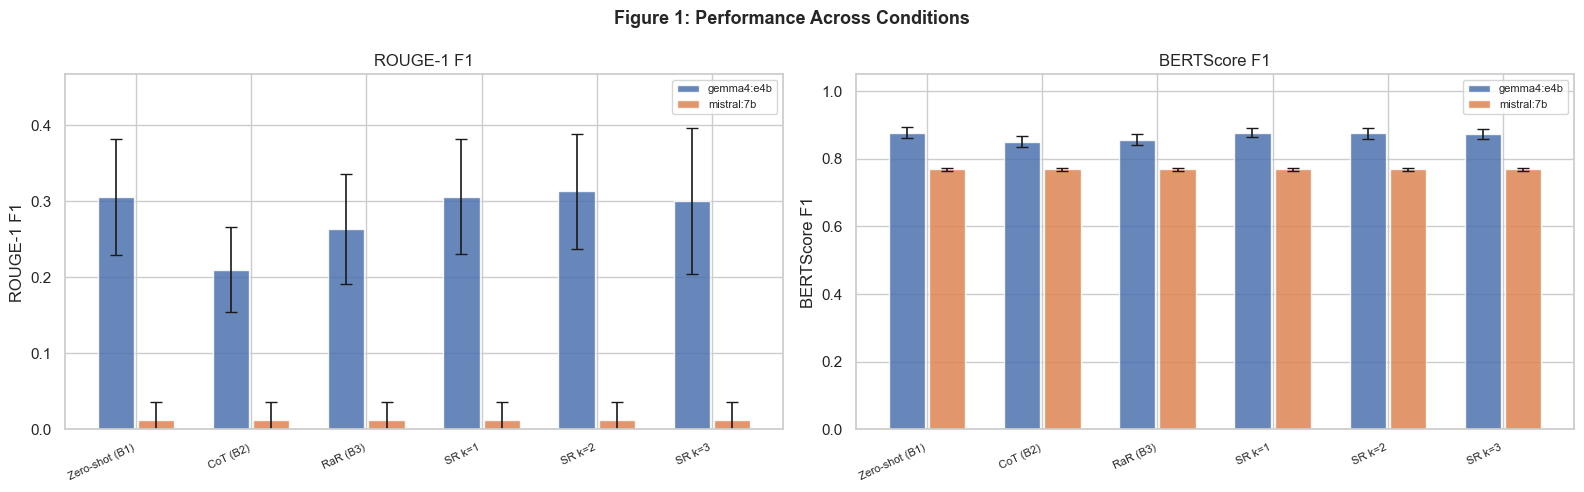

Saved fig1_performance_by_condition.png


In [17]:
# ── Figure 1: ROUGE-1 & BERTScore across conditions ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Figure 1: Performance Across Conditions", fontsize=13, fontweight="bold")
colors = ["#4C72B0", "#DD8452"]

for ax, (metric, label) in zip(axes, [("rouge1", "ROUGE-1 F1"), ("bertscore_f1", "BERTScore F1")]):
    x = np.arange(len(COND_ORDER))
    w = 0.35
    for i, (model, color) in enumerate(zip(ACTIVE_MODELS, colors)):
        means = [df[(df["model"]==model) & (df["condition"]==c)][metric].mean() for c in COND_ORDER]
        stds  = [df[(df["model"]==model) & (df["condition"]==c)][metric].std()  for c in COND_ORDER]
        offset = (i - len(ACTIVE_MODELS)/2 + 0.5) * w
        ax.bar(x + offset, means, w*0.9, yerr=stds, capsize=4,
               label=model, color=color, alpha=0.85, error_kw={"linewidth":1.2})
    ax.set_xticks(x)
    ax.set_xticklabels([COND_LABELS[c] for c in COND_ORDER], rotation=25, ha="right", fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig1_performance_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1_performance_by_condition.png")


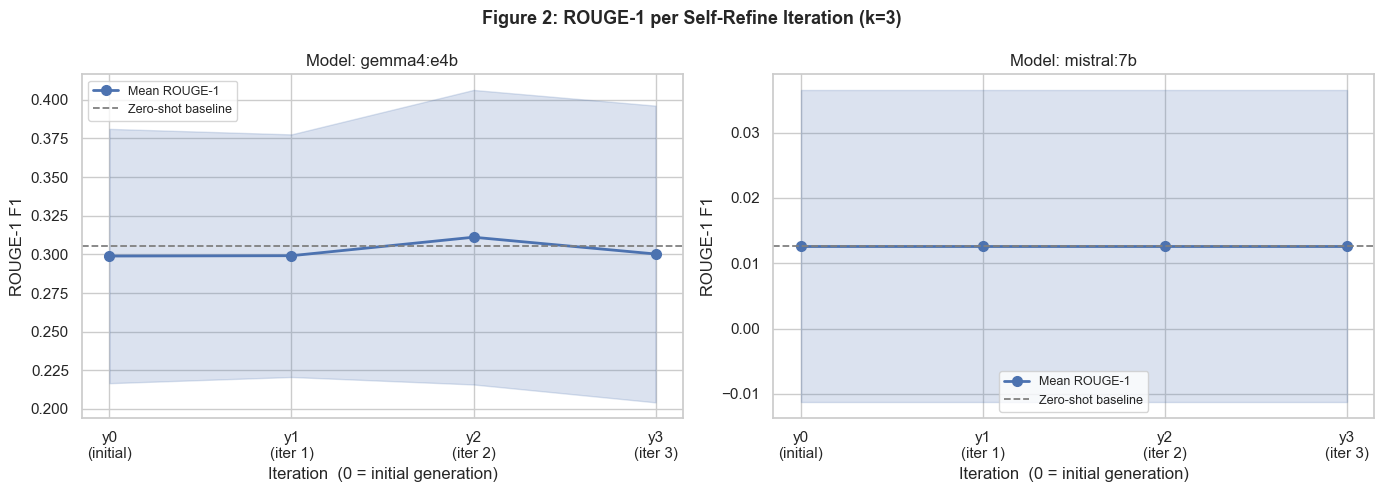

Saved fig2_iteration_rouge.png


In [18]:
#  Figure 2: ROUGE-1 per iteration (SR-3 deep dive) 
sr3_results = [r for r in all_results if r["condition"] == "sr_3"]

if sr3_results:
    iter_rows = []
    for r in sr3_results:
        for i, out in enumerate(r.get("outputs", [r["output"]])):
            rouge = compute_rouge(out, r["reference"])
            iter_rows.append({"model": r["model"], "id": r["id"],
                               "iteration": i, "rouge1": rouge["rouge1"]})
    iter_df = pd.DataFrame(iter_rows)

    n_models = len(ACTIVE_MODELS)
    fig, axes = plt.subplots(1, max(n_models, 1), figsize=(7 * n_models, 5))
    if n_models == 1:
        axes = [axes]
    fig.suptitle("Figure 2: ROUGE-1 per Self-Refine Iteration (k=3)", fontsize=13, fontweight="bold")

    for ax, model in zip(axes, ACTIVE_MODELS):
        mdf = iter_df[iter_df["model"] == model]
        means = mdf.groupby("iteration")["rouge1"].mean()
        stds  = mdf.groupby("iteration")["rouge1"].std()
        ax.plot(means.index, means.values, marker="o", lw=2, ms=7, color="#4C72B0", label="Mean ROUGE-1")
        ax.fill_between(means.index, means - stds, means + stds, alpha=0.2, color="#4C72B0")
        zs = df[(df["model"]==model) & (df["condition"]=="zero_shot")]["rouge1"].mean()
        ax.axhline(zs, ls="--", color="gray", lw=1.3, label="Zero-shot baseline")
        ax.set_xlabel("Iteration  (0 = initial generation)")
        ax.set_ylabel("ROUGE-1 F1")
        ax.set_title(f"Model: {model}")
        ax.set_xticks([0, 1, 2, 3])
        ax.set_xticklabels(["y0\n(initial)", "y1\n(iter 1)", "y2\n(iter 2)", "y3\n(iter 3)"])
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/fig2_iteration_rouge.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig2_iteration_rouge.png")
else:
    print("No SR-3 results found — run Section 6 first.")


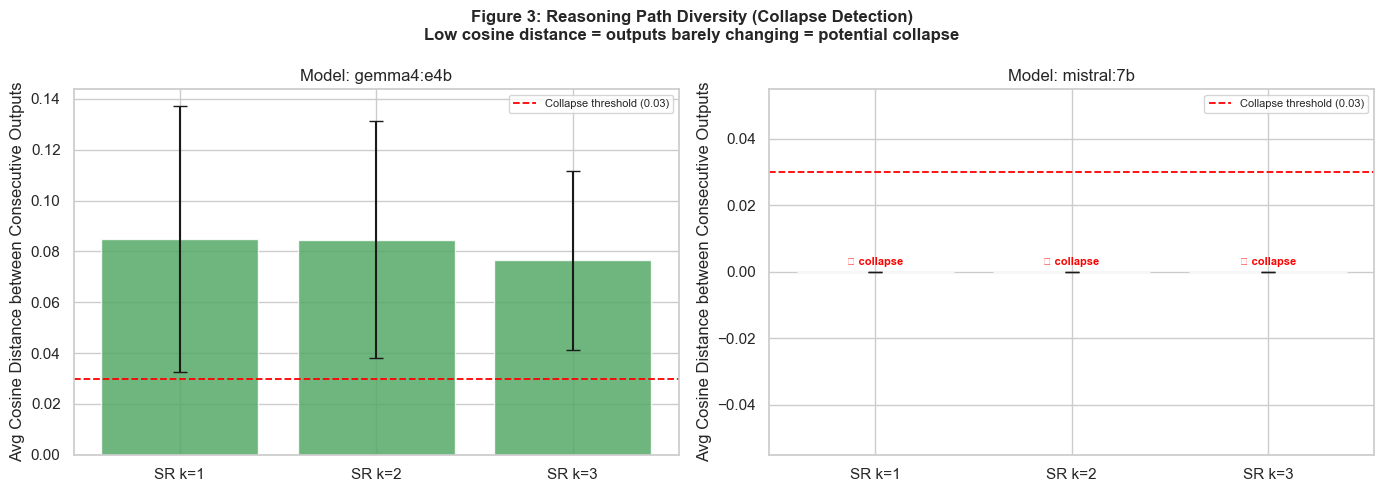

Saved fig3_diversity_collapse.png


In [19]:
# Figure 3: Diversity / collapse detection 
sr_conds = ["sr_1", "sr_2", "sr_3"]
n_models  = len(ACTIVE_MODELS)
fig, axes = plt.subplots(1, max(n_models, 1), figsize=(7 * n_models, 5))
if n_models == 1:
    axes = [axes]
fig.suptitle("Figure 3: Reasoning Path Diversity (Collapse Detection)\n"
             "Low cosine distance = outputs barely changing = potential collapse",
             fontsize=12, fontweight="bold")

COLLAPSE_THRESH = 0.03
for ax, model in zip(axes, ACTIVE_MODELS):
    mdf = df[df["model"] == model]
    means = [mdf[mdf["condition"]==c]["diversity"].mean() for c in sr_conds]
    stds  = [mdf[mdf["condition"]==c]["diversity"].std()  for c in sr_conds]
    bars  = ax.bar([COND_LABELS[c] for c in sr_conds], means, yerr=stds,
                   capsize=5, color="#55A868", alpha=0.85)
    ax.axhline(COLLAPSE_THRESH, ls="--", color="red", lw=1.3, label=f"Collapse threshold ({COLLAPSE_THRESH})")
    for i, m in enumerate(means):
        if m < COLLAPSE_THRESH:
            ax.text(i, m + 0.002, "⚠ collapse", ha="center", fontsize=8, color="red", fontweight="bold")
    ax.set_ylabel("Avg Cosine Distance between Consecutive Outputs")
    ax.set_title(f"Model: {model}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig3_diversity_collapse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_diversity_collapse.png")


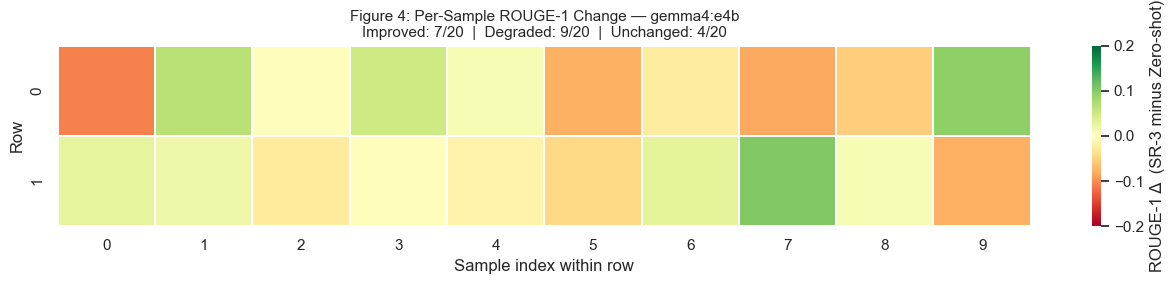

gemma4:e4b: 7 improved, 9 degraded, 4 unchanged


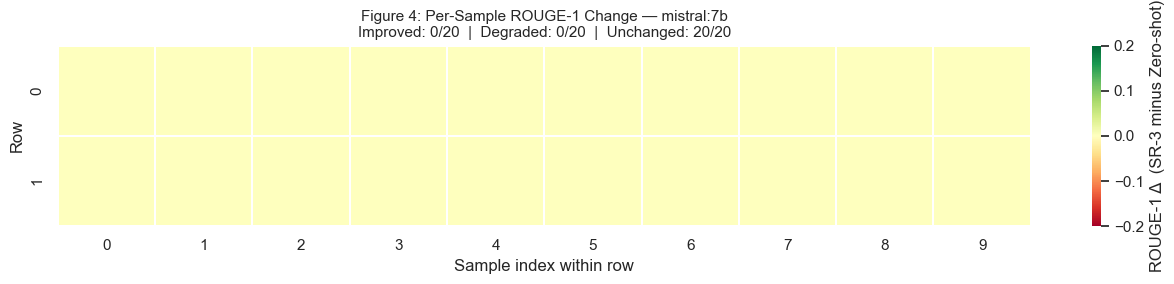

mistral:7b: 0 improved, 0 degraded, 20 unchanged


In [20]:
#  Figure 4: Per-sample heatmap (SR-3 Δ vs Zero-shot) 
for model in ACTIVE_MODELS:
    zs  = df[(df["model"]==model) & (df["condition"]=="zero_shot")].set_index("id")["rouge1"]
    sr3 = df[(df["model"]==model) & (df["condition"]=="sr_3")].set_index("id")["rouge1"]
    ids = zs.index.intersection(sr3.index)
    if len(ids) == 0:
        print(f"No overlapping IDs for {model}")
        continue
    deltas = sr3.loc[ids] - zs.loc[ids]
    n = len(deltas)
    w = min(10, n)
    h = int(np.ceil(n / w))
    grid = np.concatenate([deltas.values, np.full(w*h - n, np.nan)]).reshape(h, w)

    fig, ax = plt.subplots(figsize=(13, max(3, h)))
    sns.heatmap(grid, ax=ax, cmap="RdYlGn", center=0, vmin=-0.2, vmax=0.2,
                linewidths=0.3, linecolor="white",
                cbar_kws={"label": "ROUGE-1 Δ  (SR-3 minus Zero-shot)"})
    improved  = int((deltas >  0.01).sum())
    degraded  = int((deltas < -0.01).sum())
    unchanged = n - improved - degraded
    ax.set_title(
        f"Figure 4: Per-Sample ROUGE-1 Change — {model}\n"
        f"Improved: {improved}/{n}  |  Degraded: {degraded}/{n}  |  Unchanged: {unchanged}/{n}",
        fontsize=11,
    )
    ax.set_xlabel("Sample index within row")
    ax.set_ylabel("Row")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/fig4_heatmap_{model.replace(':','_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{model}: {improved} improved, {degraded} degraded, {unchanged} unchanged")


## 10. Error Analysis

**Required per the assignment rubric — directly determines grade.**

We categorize every SR-3 result into one of four outcomes:
- **A) Improved:** ROUGE-1 increases by > 0.02
- **B) Degraded:** ROUGE-1 decreases by > 0.02
- **C) Collapse:** diversity score < 0.03 (model rewriting nearly identical text)
- **D) Neutral:** no meaningful change


In [21]:
IMPROVE_THRESH  = 0.02
COLLAPSE_THRESH = 0.03

cat_rows = []
for r in all_results:
    if r["condition"] != "sr_3":
        continue
    outputs   = r.get("outputs", [r["output"]])
    ref       = r["reference"]
    rouge_y0  = compute_rouge(outputs[0],  ref)["rouge1"] if outputs else 0
    rouge_yn  = compute_rouge(outputs[-1], ref)["rouge1"] if outputs else 0
    diversity = compute_diversity(outputs)
    delta     = rouge_yn - rouge_y0

    if diversity < COLLAPSE_THRESH:
        category = "C) Collapse"
    elif delta > IMPROVE_THRESH:
        category = "A) Improved"
    elif delta < -IMPROVE_THRESH:
        category = "B) Degraded"
    else:
        category = "D) Neutral"

    cat_rows.append({
        "id": r["id"], "model": r["model"], "category": category,
        "delta_rouge1": round(delta, 4), "diversity": diversity,
        "rouge_y0": rouge_y0, "rouge_yn": rouge_yn,
        "outputs": outputs, "feedbacks": r.get("feedbacks", []),
        "reference": ref,
    })

cat_df = pd.DataFrame(cat_rows)

print("\n=== FAILURE MODE DISTRIBUTION ===\n")
for model in ACTIVE_MODELS:
    mdf   = cat_df[cat_df["model"] == model]
    total = len(mdf)
    print(f"Model: {model}  (n={total})")
    for cat, cnt in mdf["category"].value_counts().sort_index().items():
        print(f"  {cat}: {cnt:3d}  ({100*cnt/total:.1f}%)")
    print()



=== FAILURE MODE DISTRIBUTION ===

Model: gemma4:e4b  (n=20)
  A) Improved:   7  (35.0%)
  B) Degraded:   6  (30.0%)
  C) Collapse:   1  (5.0%)
  D) Neutral:   6  (30.0%)

Model: mistral:7b  (n=20)
  C) Collapse:  20  (100.0%)



In [22]:
def show_example(row: dict, label: str):
    """Pretty-print one annotated example."""
    SEP = "─" * 70
    print(f"\n{SEP}")
    print(f"[{label}]   id={row['id']}   model={row['model']}")
    print(f"ROUGE-1:  y0={row['rouge_y0']:.4f}  →  yn={row['rouge_yn']:.4f}   "
          f"Δ={row['delta_rouge1']:+.4f}   Diversity={row['diversity']:.4f}")
    print(f"\nREFERENCE:\n  {row['reference'][:350]}")
    print(f"\nINITIAL OUTPUT (y0):\n  {row['outputs'][0][:350]}")
    if row["feedbacks"]:
        print(f"\nFEEDBACK (fb1):\n  {row['feedbacks'][0][:350]}")
    print(f"\nFINAL OUTPUT (y3):\n  {row['outputs'][-1][:350]}")


primary_cat = cat_df[cat_df["model"] == PRIMARY_MODEL]

for label in ["A) Improved", "B) Degraded", "C) Collapse", "D) Neutral"]:
    sub = primary_cat[primary_cat["category"] == label]
    if len(sub) == 0:
        print(f"\n[{label}] No examples found.")
        continue
    # Pick most extreme case for each category
    ascending = (label == "B) Degraded")
    best_row  = sub.sort_values("delta_rouge1", ascending=ascending).iloc[0]
    show_example(best_row.to_dict(), label)



──────────────────────────────────────────────────────────────────────
[A) Improved]   id=cnn_017   model=gemma4:e4b
ROUGE-1:  y0=0.2479  →  yn=0.3717   Δ=+0.1238   Diversity=0.1032

REFERENCE:
  Marseille prosecutor says "so far no videos were used in the crash investigation" despite media reports . Journalists at Bild and Paris Match are "very confident" the video clip is real, an editor says . Andreas Lubitz had informed his Lufthansa training school of an episode of severe depression, airline says .

INITIAL OUTPUT (y0):
  The French prosecutor investigating the Germanwings Flight 9525 crash stated that no onboard video footage has been used in the investigation and urged anyone with such video to provide it to authorities. These comments contradict reports from *Bild* and *Paris Match* magazines, which claimed to have viewed a cell phone video from the crash site. O

FEEDBACK (fb1):
  1. Missing the specific name of the prosecutor who made the statement (should be Brice Robin).
2

In [23]:
#  Feedback quality: do improved cases have more specific feedback? 
print("\n=== FEEDBACK QUALITY ANALYSIS ===\n")
GENERIC_KEYWORDS = ["better", "improve", "more detail", "unclear", "vague",
                    "needs work", "good job", "well done"]

for model in ACTIVE_MODELS:
    mdf = cat_df[cat_df["model"] == model]
    print(f"Model: {model}")
    for cat in ["A) Improved", "B) Degraded", "C) Collapse"]:
        sub = mdf[mdf["category"] == cat]
        if len(sub) == 0:
            continue
        all_fbs = [fb for fbs in sub["feedbacks"] for fb in fbs]
        if not all_fbs:
            continue
        avg_len      = np.mean([len(fb.split()) for fb in all_fbs])
        generic_rate = np.mean([any(kw in fb.lower() for kw in GENERIC_KEYWORDS)
                                for fb in all_fbs])
        print(f"  {cat}: avg feedback words = {avg_len:.1f},  "
              f"generic rate = {generic_rate:.1%}")
    print()



=== FEEDBACK QUALITY ANALYSIS ===

Model: gemma4:e4b
  A) Improved: avg feedback words = 56.1,  generic rate = 0.0%
  B) Degraded: avg feedback words = 59.7,  generic rate = 5.6%
  C) Collapse: avg feedback words = 64.3,  generic rate = 0.0%

Model: mistral:7b
  C) Collapse: avg feedback words = 8.0,  generic rate = 0.0%



## 11. Ablation Studies

**Ablation 1:** Best-of-k vs Final-k — is stopping at k=3 always optimal?
**Ablation 2:** Feedback temperature — does lower temperature produce more useful feedback?


In [24]:
#  Ablation 1: Best-of-k vs Final-k =
print("=== ABLATION 1: Best-of-k vs Final-k ===")
print("For each SR-3 sample, which iteration produced the highest ROUGE-1?\n")

for model in ACTIVE_MODELS:
    sr3 = [r for r in all_results if r["condition"] == "sr_3" and r["model"] == model]
    if not sr3:
        print(f"No SR-3 results for {model}")
        continue
    best_k_dist = {0: 0, 1: 0, 2: 0, 3: 0}
    final_r1s, best_r1s = [], []
    for r in sr3:
        outputs = r.get("outputs", [r["output"]])
        rouges  = [compute_rouge(o, r["reference"])["rouge1"] for o in outputs]
        best_k  = int(np.argmax(rouges))
        best_k_dist[min(best_k, 3)] = best_k_dist.get(min(best_k, 3), 0) + 1
        final_r1s.append(rouges[-1])
        best_r1s.append(rouges[best_k])

    n = len(sr3)
    print(f"Model: {model}  (n={n})")
    print("  Best ROUGE-1 was achieved at iteration:")
    for k, cnt in sorted(best_k_dist.items()):
        bar = "█" * int(20 * cnt / n)
        print(f"    k={k}: {cnt:3d} samples ({100*cnt/n:.1f}%)  {bar}")
    print(f"  Mean ROUGE-1  —  final y3: {np.mean(final_r1s):.4f}  |  oracle best-k: {np.mean(best_r1s):.4f}")
    print(f"  Oracle gain from best-k selection: {np.mean(best_r1s) - np.mean(final_r1s):+.4f}")
    print()


=== ABLATION 1: Best-of-k vs Final-k ===
For each SR-3 sample, which iteration produced the highest ROUGE-1?

Model: gemma4:e4b  (n=20)
  Best ROUGE-1 was achieved at iteration:
    k=0:   8 samples (40.0%)  ████████
    k=1:   1 samples (5.0%)  █
    k=2:   6 samples (30.0%)  ██████
    k=3:   5 samples (25.0%)  █████
  Mean ROUGE-1  —  final y3: 0.3002  |  oracle best-k: 0.3406
  Oracle gain from best-k selection: +0.0404

Model: mistral:7b  (n=20)
  Best ROUGE-1 was achieved at iteration:
    k=0:  20 samples (100.0%)  ████████████████████
    k=1:   0 samples (0.0%)  
    k=2:   0 samples (0.0%)  
    k=3:   0 samples (0.0%)  
  Mean ROUGE-1  —  final y3: 0.0126  |  oracle best-k: 0.0126
  Oracle gain from best-k selection: +0.0000



In [25]:
#  Ablation 2: Feedback temperature effect (10 samples, primary model) 
print("=== ABLATION 2: Feedback Temperature ===")
print("Low temp (0.1) = deterministic feedback | High temp (0.5) = varied feedback\n")

ABLATION_N     = 10
ABLATION_TEMPS = [0.1, 0.5]
abl_samples    = cnn_samples[:ABLATION_N]
abl_results    = {}

for fb_temp in ABLATION_TEMPS:
    print(f"Running feedback_temp={fb_temp} on {ABLATION_N} samples...")
    rows = []
    for sample in tqdm(abl_samples, desc=f"fb_temp={fb_temp}"):
        outputs, feedbacks = [], []
        y = call_ollama(P_zero_shot(sample["article"]), model=PRIMARY_MODEL,
                        temperature=TEMPERATURE, max_tokens=MAX_TOKENS_GEN)
        outputs.append(y)
        for _ in range(2):
            fb = call_ollama(P_feedback(sample["article"], outputs[-1]),
                             model=PRIMARY_MODEL, temperature=fb_temp, max_tokens=MAX_TOKENS_FB)
            feedbacks.append(fb)
            refined = call_ollama(P_refine(sample["article"], outputs[-1], fb),
                                  model=PRIMARY_MODEL, temperature=TEMPERATURE, max_tokens=MAX_TOKENS_GEN)
            outputs.append(refined)
        r0 = compute_rouge(outputs[0],  sample["reference"])["rouge1"]
        rn = compute_rouge(outputs[-1], sample["reference"])["rouge1"]
        rows.append({
            "fb_temp": fb_temp, "rouge_init": r0, "rouge_final": rn,
            "delta": rn - r0,
            "fb_avg_len": np.mean([len(fb.split()) for fb in feedbacks]),
            "diversity": compute_diversity(outputs),
        })
    abl_results[fb_temp] = pd.DataFrame(rows)

print("\nResults:")
for temp, adf in abl_results.items():
    print(f"  feedback_temp={temp}:")
    print(f"    Mean ROUGE-1 delta : {adf['delta'].mean():+.4f}")
    print(f"    Avg feedback length: {adf['fb_avg_len'].mean():.1f} words")
    print(f"    Avg diversity score: {adf['diversity'].mean():.4f}")


=== ABLATION 2: Feedback Temperature ===
Low temp (0.1) = deterministic feedback | High temp (0.5) = varied feedback

Running feedback_temp=0.1 on 10 samples...


fb_temp=0.1: 100%|██████████| 10/10 [07:19<00:00, 43.93s/it]


Running feedback_temp=0.5 on 10 samples...


fb_temp=0.5: 100%|██████████| 10/10 [06:59<00:00, 41.95s/it]


Results:
  feedback_temp=0.1:
    Mean ROUGE-1 delta : +0.0115
    Avg feedback length: 56.4 words
    Avg diversity score: 0.0768
  feedback_temp=0.5:
    Mean ROUGE-1 delta : +0.0181
    Avg feedback length: 54.8 words
    Avg diversity score: 0.0698


## 12. Hypothesis Evaluation & Discussion

In [26]:
HYPOTHESES = [
    ("H1",
     "Small LLMs (3B) show minimal or no improvement from self-refinement and may degrade by k=3.",
     "self-refine fails to help small models"),
    ("H2",
     "Medium models (7B) show modest improvement at k=1,2 but plateau or collapse at k=3.",
     "refinement saturates early for medium models"),
    ("H3",
     "RaR (input-side) outperforms output-side Self-Refine for small models.",
     "input-side refinement more robust than output-side"),
    ("H4",
     "Feedback quality degrades with model size — small models produce vague, repetitive feedback.",
     "poor feedback is the bottleneck for small model refinement"),
]

print("=" * 70)
print("HYPOTHESIS EVALUATION")
print("=" * 70)

for hid, htext, _ in HYPOTHESES:
    print(f"\n{hid}: {htext}")
    if PRIMARY_MODEL not in df["model"].values:
        print("  ► Cannot evaluate — no results yet.")
        continue
    pm = df[df["model"] == PRIMARY_MODEL]
    zs_r1  = pm[pm["condition"]=="zero_shot"]["rouge1"].mean()
    sr3_r1 = pm[pm["condition"]=="sr_3"]["rouge1"].mean()
    sr1_r1 = pm[pm["condition"]=="sr_1"]["rouge1"].mean()
    rar_r1 = pm[pm["condition"]=="rar"]["rouge1"].mean()

    if hid == "H1":
        supported = sr3_r1 <= zs_r1 + 0.01
        evidence  = f"SR-3={sr3_r1:.4f} vs Zero-shot={zs_r1:.4f} (Δ={sr3_r1-zs_r1:+.4f})"
    elif hid == "H2":
        if SECONDARY_MODEL and SECONDARY_MODEL in df["model"].values:
            sm = df[df["model"]==SECONDARY_MODEL]
            sm_sr1 = sm[sm["condition"]=="sr_1"]["rouge1"].mean()
            sm_sr3 = sm[sm["condition"]=="sr_3"]["rouge1"].mean()
            supported = sm_sr1 >= sm_sr3
            evidence  = f"{SECONDARY_MODEL}: SR-1={sm_sr1:.4f}, SR-3={sm_sr3:.4f}"
        else:
            supported = None
            evidence  = "Only one model tested — H2 requires the secondary model."
    elif hid == "H3":
        supported = rar_r1 >= sr3_r1
        evidence  = f"RaR={rar_r1:.4f} vs SR-3={sr3_r1:.4f} (Δ={rar_r1-sr3_r1:+.4f})"
    elif hid == "H4":
        if cat_df is not None and len(cat_df) > 0:
            pm_cat = cat_df[cat_df["model"]==PRIMARY_MODEL]
            collapse_pct = (pm_cat["category"]=="C) Collapse").mean()
            supported = collapse_pct > 0.2
            evidence  = f"Collapse rate={collapse_pct:.1%} for {PRIMARY_MODEL}"
        else:
            supported = None
            evidence  = "Run error analysis first."
    else:
        supported, evidence = None, "N/A"

    verdict = ("SUPPORTED" if supported else "NOT SUPPORTED") if supported is not None else "UNTESTABLE"
    print(f"  Evidence: {evidence}")
    print(f"  ► VERDICT: {verdict}")


HYPOTHESIS EVALUATION

H1: Small LLMs (3B) show minimal or no improvement from self-refinement and may degrade by k=3.
  Evidence: SR-3=0.3002 vs Zero-shot=0.3055 (Δ=-0.0052)
  ► VERDICT: SUPPORTED

H2: Medium models (7B) show modest improvement at k=1,2 but plateau or collapse at k=3.
  Evidence: mistral:7b: SR-1=0.0126, SR-3=0.0126
  ► VERDICT: SUPPORTED

H3: RaR (input-side) outperforms output-side Self-Refine for small models.
  Evidence: RaR=0.2633 vs SR-3=0.3002 (Δ=-0.0369)
  ► VERDICT: NOT SUPPORTED

H4: Feedback quality degrades with model size — small models produce vague, repetitive feedback.
  Evidence: Collapse rate=5.0% for gemma4:e4b
  ► VERDICT: NOT SUPPORTED


In [27]:
#  Final Summary Table (paper-ready) 
print("\n" + "=" * 70)
print("SUMMARY TABLE (copy to LaTeX)")
print("=" * 70)

latex_rows = []
for model in ACTIVE_MODELS:
    mdf = df[df["model"] == model]
    for cond in COND_ORDER:
        cdf = mdf[mdf["condition"] == cond]
        if len(cdf) == 0:
            continue
        latex_rows.append({
            "Model":      model,
            "Condition":  COND_LABELS[cond],
            "ROUGE-1":    f"{cdf['rouge1'].mean():.4f} ± {cdf['rouge1'].std():.4f}",
            "ROUGE-L":    f"{cdf['rougeL'].mean():.4f}",
            "BERTScore":  f"{cdf['bertscore_f1'].mean():.4f}",
            "Diversity":  f"{cdf['diversity'].mean():.4f}",
            "Time (s)":   f"{cdf['time_s'].mean():.1f}",
        })

summary_df = pd.DataFrame(latex_rows)
print(summary_df.to_string(index=False))

print("\n")
print("Best / Worst Conditions:")
for model in ACTIVE_MODELS:
    mdf  = df[df["model"]==model]
    best = mdf.groupby("condition")["rouge1"].mean().idxmax()
    worst= mdf.groupby("condition")["rouge1"].mean().idxmin()
    print(f"  {model}:  best={COND_LABELS[best]}  |  worst={COND_LABELS[worst]}")

print(f"\nAll plots and checkpoints saved to: {os.path.abspath(RESULTS_DIR)}/")



SUMMARY TABLE (copy to LaTeX)
     Model      Condition         ROUGE-1 ROUGE-L BERTScore Diversity Time (s)
gemma4:e4b Zero-shot (B1) 0.3055 ± 0.0768  0.2048    0.8774    0.0000      8.4
gemma4:e4b       CoT (B2) 0.2099 ± 0.0562  0.1503    0.8504    0.0000     16.3
gemma4:e4b       RaR (B3) 0.2633 ± 0.0718  0.1798    0.8562    0.0000     11.0
gemma4:e4b         SR k=1 0.3059 ± 0.0757  0.1976    0.8773    0.0848     26.1
gemma4:e4b         SR k=2 0.3132 ± 0.0755  0.2116    0.8747    0.0846     44.1
gemma4:e4b         SR k=3 0.3002 ± 0.0960  0.2083    0.8729    0.0765     64.0
mistral:7b Zero-shot (B1) 0.0126 ± 0.0239  0.0091    0.7684    0.0000      2.0
mistral:7b       CoT (B2) 0.0126 ± 0.0239  0.0091    0.7684    0.0000      2.0
mistral:7b       RaR (B3) 0.0126 ± 0.0239  0.0091    0.7684    0.0000      2.0
mistral:7b         SR k=1 0.0126 ± 0.0239  0.0091    0.7684    0.0000      6.1
mistral:7b         SR k=2 0.0126 ± 0.0239  0.0091    0.7684    0.0000     10.2
mistral:7b         SR